In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pywt

import os
os.chdir("../../..")

from scripts.NEURON_Sim_Wrapper import Network

In [11]:
file_path = "./Datasets/Generated/Experiments/Syn_Delay_Experiments/3k_70con_1000ms_stim_8980589_100ms_05syndelay.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)
    
t = data['t']
voltages = data['voltages']

sr = 0.00025

print(f"t: {len(t)} sampls ({len(t) * sr} sec) ")               
print("neurons:", len(list(voltages.keys())))
print("voltages:", len(voltages["8980589"]))

t: 4001 sampls (1.00025 sec) 
neurons: 3016
voltages: 4001


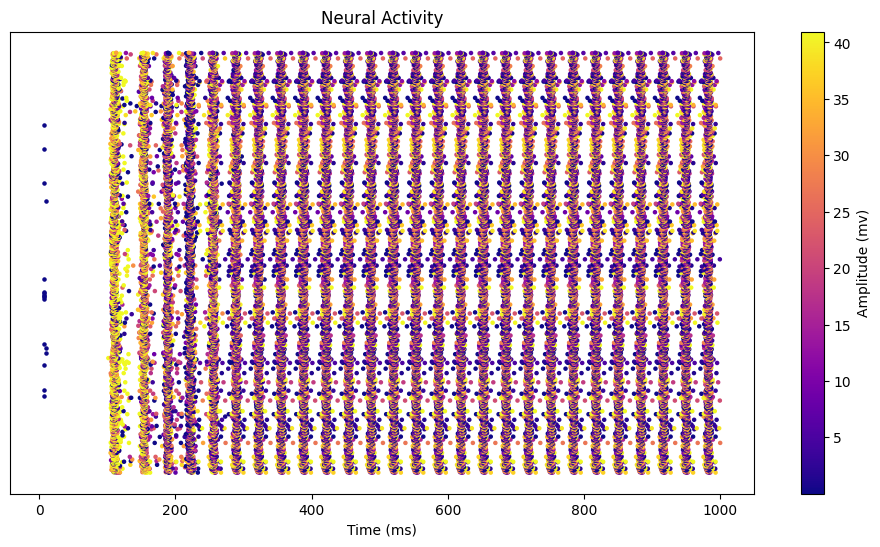

In [12]:
spike_times, spike_amps = Network.analyze(self=None, t=t, voltages=voltages)


# создание графика
fig, ax = plt.subplots(figsize=(12, 6))

# итерация по нейронам
amps_values = []
for i, neuron_id in enumerate(spike_times):
    times = spike_times[neuron_id]
    amps = spike_amps[neuron_id]

    # рисование спайков
    ax.scatter(times, [i] * len(times), s=5, c=amps, cmap='plasma')
    amps_values.extend(amps)

# настройка графика
ax.set_xlabel('Time (ms)')
ax.set_yticks([])  # убираем отметки на оси Y
ax.set_title('Neural Activity')

# добавление цветовой шкалы
if amps_values:  # проверяем, что список не пуст
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(vmin=min(amps_values), vmax=max(amps_values))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Amplitude (mv)')

# отображение графика
plt.show()

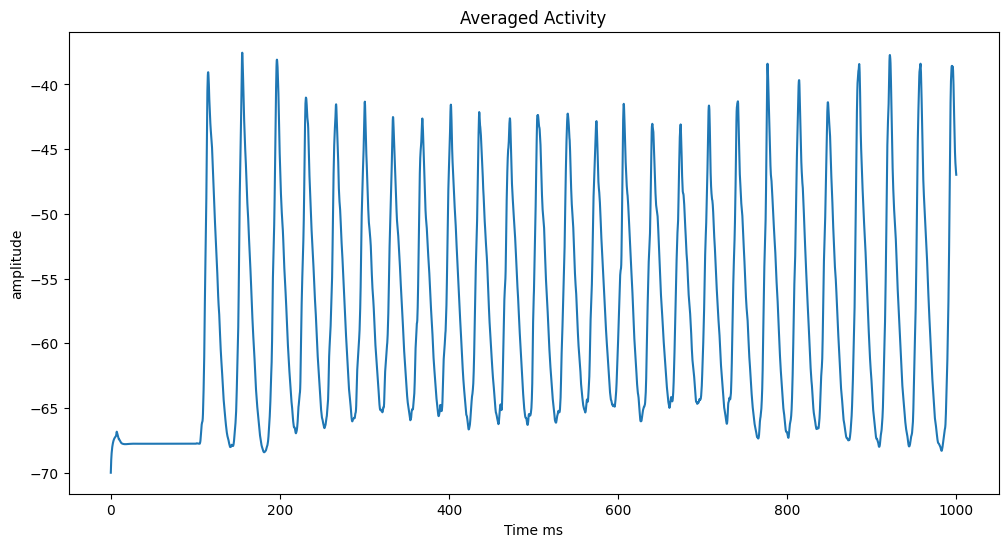

In [5]:
# извлекаем напряжения всех нейронов
all_voltages = list(voltages.values())

# усредняем напряжения по нейронам
averaged_voltages = np.mean(all_voltages, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(t, averaged_voltages)
plt.xlabel('Time ms')
plt.ylabel('amplitude')
plt.title('Averaged Activity')
plt.show()

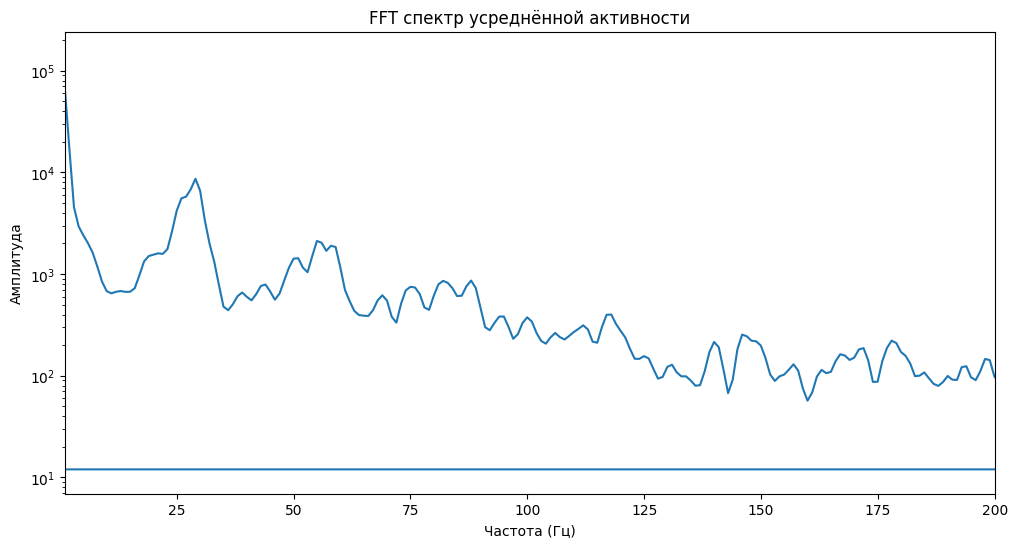

In [6]:
# извлекаем напряжения всех нейронов
all_voltages = list(voltages.values())

# усредняем напряжения по нейронам
averaged_voltages = np.mean(all_voltages, axis=0)

# применяем FFT к усреднённым напряжениям
fft = np.fft.fft(averaged_voltages)
freqs = np.fft.fftfreq(len(t), d=sr)

# сглаживаем спектр
sigma = 1  # параметр сглаживания (подбери подходящее значение)
smoothed_fft = gaussian_filter1d(np.abs(fft), sigma)
# smoothed_fft = np.abs(fft)

# рисуем спектр
plt.figure(figsize=(12, 6))
plt.plot(freqs, smoothed_fft)
plt.xlim([1, 200])
# plt.ylim([-10000, 10000])
plt.yscale('log')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('FFT спектр усреднённой активности')
plt.show()

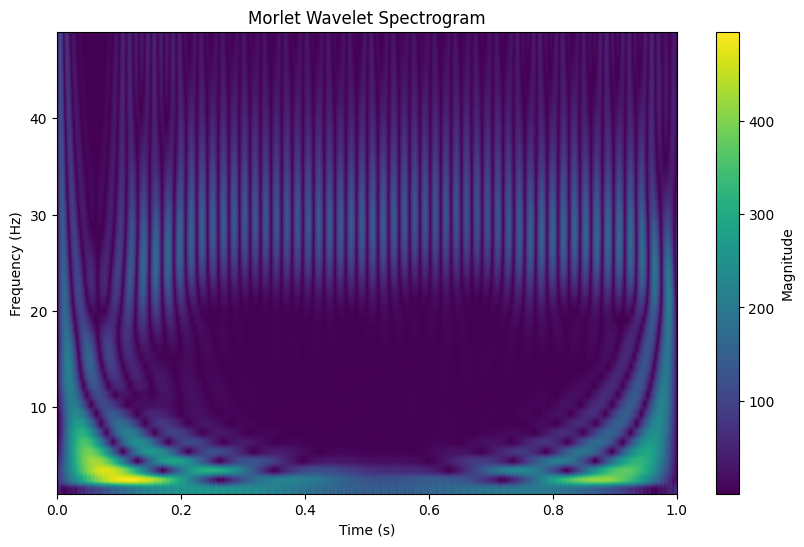

In [7]:
# выбираем вейвлет Морлета
wavelet = 'morl'
max_freq = 50 # Hz
resolution = 1 # Hz


freqs = np.arange(1, max_freq, resolution)
fc = pywt.central_frequency(wavelet)  # ≈ 0.8125
scales = fc / (freqs * sr)

coef, freqs_wavelet = pywt.cwt(averaged_voltages, scales, wavelet, sampling_period=sr)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.imshow(
    np.abs(coef),
    extent=[0, 1, freqs_wavelet.min(), freqs_wavelet.max()],
    aspect="auto",
    origin="lower"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Morlet Wavelet Spectrogram")
plt.colorbar(label="Magnitude")

plt.show()